ROOT: /Users/arsii/Documents/Fishcast-Maps
DATA: /Users/arsii/Documents/Fishcast-Maps/Data/HSI_layang_full_grid.csv
MODEL: /Users/arsii/Documents/Fishcast-Maps/Models/rf_layang_model.joblib


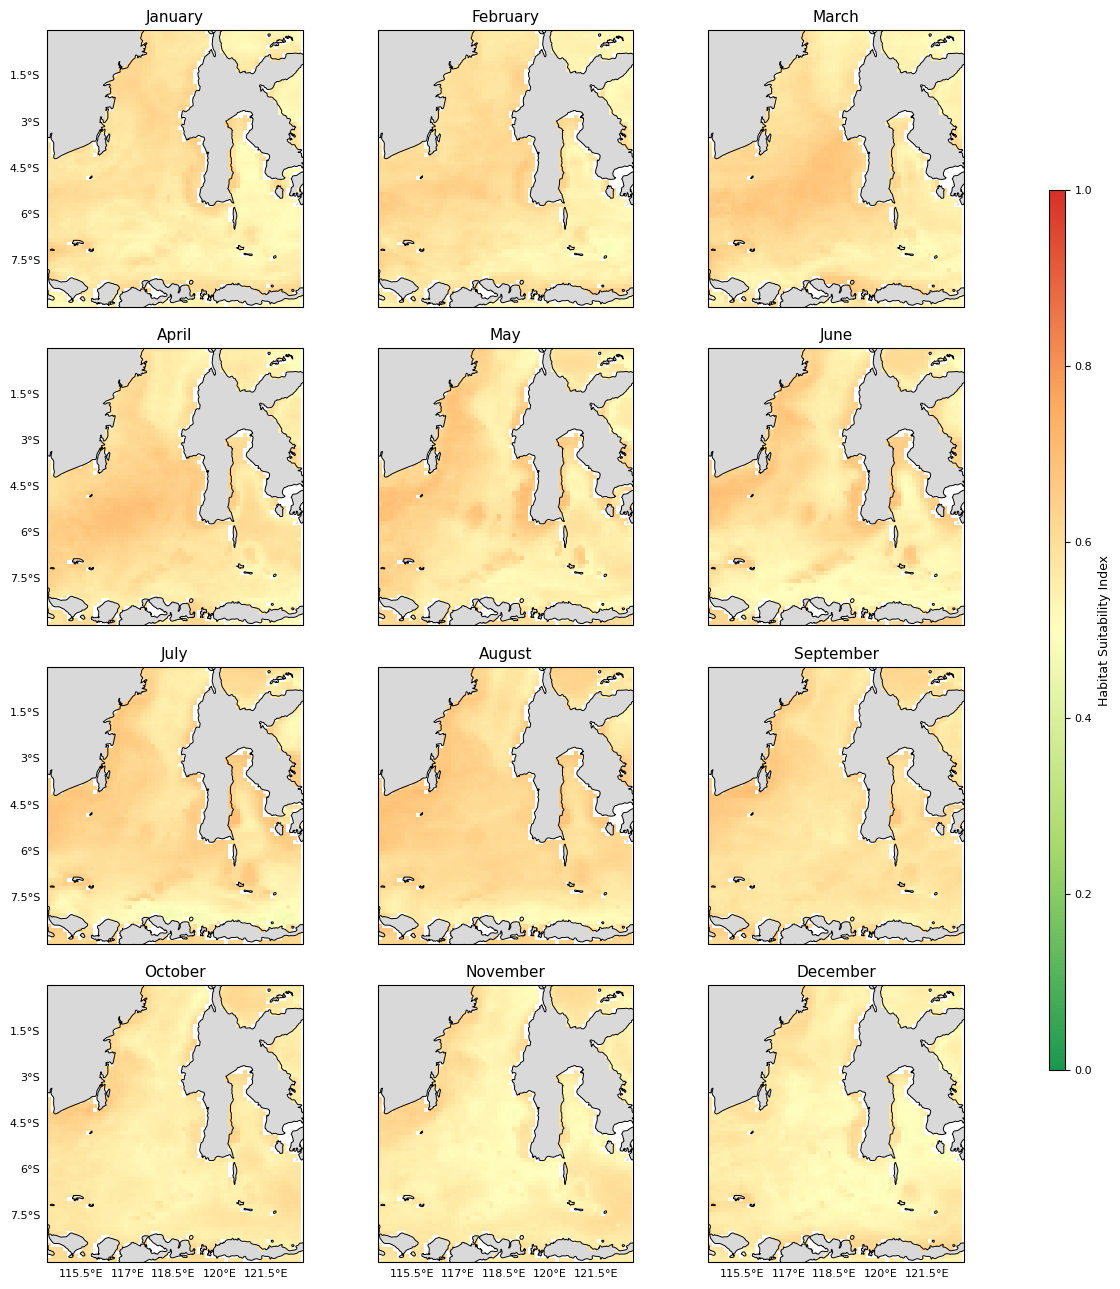

In [7]:
# ==============================
# Import
# ==============================
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter


# ==============================
# AUTO ROOT
# ==============================
ROOT = Path.cwd()

while not (ROOT / "Models").exists():
    ROOT = ROOT.parent

DATA_FILE  = ROOT / "Data" / "HSI_layang_full_grid.csv"
PATH_MODEL = ROOT / "Models" / "rf_layang_model.joblib"
OUTPUT_DIR = ROOT / "Maps"

OUTPUT_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA_FILE)
print("MODEL:", PATH_MODEL)


# ==============================
# DOMAIN
# ==============================
LAT_MIN, LAT_MAX = -9.0, 0.0
LON_MIN, LON_MAX = 114.4, 122.7

GRID_RES = 0.125
CHUNKSIZE = 1_000_000


# ==============================
# FILTER DOMAIN
# ==============================
def filter_domain(df):

    m = (
        df["lat"].between(LAT_MIN, LAT_MAX) &
        df["lon"].between(LON_MIN, LON_MAX)
    )

    return df.loc[m].copy()


# ==============================
# SPATIAL BIN
# ==============================
def add_spatial_bins(df, res):

    df = df.copy()

    df["lat_bin"] = np.floor((df["lat"] - LAT_MIN) / res).astype(int)
    df["lon_bin"] = np.floor((df["lon"] - LON_MIN) / res).astype(int)

    df["lat_c"] = LAT_MIN + (df["lat_bin"] + 0.5) * res
    df["lon_c"] = LON_MIN + (df["lon_bin"] + 0.5) * res

    return df


# ==============================
# ITERATOR CSV BESAR
# ==============================
def iter_environment(data_file):

    for chunk in pd.read_csv(
        data_file,
        chunksize=CHUNKSIZE,
        low_memory=False
    ):

        chunk.columns = chunk.columns.str.strip()

        chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")

        chunk = chunk.dropna(subset=["date","lat","lon"])

        for c in ["SLA","EKE","SST","CHL","SSS"]:
            chunk[c] = pd.to_numeric(chunk[c], errors="coerce")

        chunk = filter_domain(chunk)

        if not chunk.empty:
            yield chunk


# ==============================
# ADD HSI
# ==============================
def add_hsi_probability(df, rf_model):

    predictors = ["SLA","EKE","SST","CHL","SSS"]

    X = df[predictors].copy()

    mask = ~X.isna().any(axis=1)

    df = df.loc[mask].copy()
    X = X.loc[mask]

    if df.empty:
        return df

    try:
        df["hsi"] = rf_model.predict_proba(X)[:,1]
    except:
        df["hsi"] = rf_model.predict(X)

    return df


# ==============================
# BUILD CLIMATOLOGY
# ==============================
def build_monthly_climatology():

    rf_model = joblib.load(PATH_MODEL)

    monthly_parts = []

    for chunk in iter_environment(DATA_FILE):

        chunk = add_hsi_probability(chunk, rf_model)

        if chunk.empty:
            continue

        chunk["month"] = chunk["date"].dt.month

        chunk = add_spatial_bins(chunk, GRID_RES)

        agg = (
            chunk.groupby(
                ["month","lat_bin","lon_bin","lat_c","lon_c"],
                as_index=False
            )
            .agg(
                sum_prob=("hsi","sum"),
                n_points=("hsi","size")
            )
        )

        monthly_parts.append(agg)

    if len(monthly_parts) == 0:
        raise RuntimeError("No valid data after prediction")

    all_agg = pd.concat(monthly_parts, ignore_index=True)

    final = (
        all_agg.groupby(
            ["month","lat_bin","lon_bin","lat_c","lon_c"],
            as_index=False
        )
        .agg(
            sum_prob=("sum_prob","sum"),
            n_points=("n_points","sum")
        )
    )

    final["hsi_mean"] = final["sum_prob"] / final["n_points"]

    return final


# ==============================
# COLORMAP
# ==============================
hsi_cmap = LinearSegmentedColormap.from_list(
    "hsi_custom",
    ["#1a9850","#a6d96a","#ffffbf","#fdae61","#d73027"]
)


# ==============================
# PLOT
# ==============================
def plot_12_months_climatology(monthly_grid, save_path=None):

    fig = plt.figure(figsize=(13,16))

    gs = fig.add_gridspec(
        4, 4,
        width_ratios=[1,1,1,0.05],
        hspace=0.15,
        wspace=0.05
    )

    axes = []
    for r in range(4):
        for c in range(3):
            ax = fig.add_subplot(gs[r,c], projection=ccrs.PlateCarree())
            axes.append(ax)

    last_im = None

    for m in range(1,13):

        ax = axes[m-1]

        ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

        ax.add_feature(cfeature.LAND, facecolor="#d9d9d9")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

        row = (m-1)//3
        col = (m-1)%3

        gl = ax.gridlines(draw_labels=True, linewidth=0, alpha=0)

        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (col == 0)
        gl.bottom_labels = (row == 3)

        gl.xlabel_style = {'size':8}
        gl.ylabel_style = {'size':8}

        gl.xformatter = LongitudeFormatter('.0f')
        gl.yformatter = LatitudeFormatter('.0f')

        d = monthly_grid[
            (monthly_grid["month"] == m) &
            (~monthly_grid["hsi_mean"].isna())
        ]

        if not d.empty:

            lats = np.sort(d["lat_c"].unique())
            lons = np.sort(d["lon_c"].unique())

            Z = (
                d.pivot(
                    index="lat_c",
                    columns="lon_c",
                    values="hsi_mean"
                )
                .reindex(index=lats, columns=lons)
                .to_numpy()
            )

            if not np.all(np.isnan(Z)):

                last_im = ax.pcolormesh(
                    lons,
                    lats,
                    Z,
                    shading="nearest",
                    cmap=hsi_cmap,
                    vmin=0,
                    vmax=1
                )

        ax.set_title(
            pd.Timestamp(month=m, year=2000, day=1).strftime("%B"),
            fontsize=11
        )

    if last_im is not None:

        cax = fig.add_axes([0.92, 0.23, 0.012, 0.55])

        cbar = fig.colorbar(last_im, cax=cax)
        cbar.set_label("Habitat Suitability Index", fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

    plt.show()


# ==============================
# RUN
# ==============================
monthly_clim = build_monthly_climatology()

plot_12_months_climatology(
    monthly_clim,
    save_path=OUTPUT_DIR / "HSI_Layang_12Months.png"
)